Date: 4th August 2026

Author: Bipul Pandey

Objectives: In this notebook we will investigate the fitness and hamming distributions between the Ground Truth and the Generated Population.

    In particular,
        - Ground Truth Population vs LRBM Generated Population
        - Ground Truth Population vs Profile Model Generated Population
            

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.colors as mcolors
from sklearn.metrics import r2_score
from scipy.stats import pearsonr
import json

import sys
sys.path.append("../Scripts/")
from Evolution import *

Evolutionary Model Used in the Paper:

In [4]:
Model_Attributes_location = "../../Model_Parameters/Evolver_simulation/Model_Attributes.json"
with open(Model_Attributes_location, 'r') as file:
    Model_Details = json.load(file)


In [5]:
print("Number of Positions =", Model_Details['Number_of_Positions'])
print("Number of Alleles per position =", Model_Details['Number_of_Alleles'])
print("")
print("Features in each partition =", Model_Details['Feature_Partition'])


Number of Positions = 16
Number of Alleles per position = 4

Features in each partition = [4, 4, 4, 4]


In [6]:
print("="*100)
for k in Model_Details.keys():
    print("||->",k, ":", Model_Details[k])
print("="*100)


||-> Feature_Partition : [4, 4, 4, 4]
||-> Number_of_Positions : 16
||-> Number_of_Alleles : 4
||-> Fitness_type : Conditional_Additive
||-> Zero_fitness_death : True
||-> Weights : [0.9920400904402258, 0.962880881706722, 0.9998765436859355, 0.971551987343159, 1.0342033078386703, 0.9976988451982086, 1.0230610082929552, 0.961248450235667, 0.520845931038242, 0.4919911061241495, 0.516498035023754, 0.5032598836570324, 0.0, 0.0, 0.0, 0.0]
||-> Mutation_Rate : 0.3
||-> Competetion_fration : 0.3
||-> Tournament_Type : Probabilistic
||-> Selection_Strength : 4
||-> Fitness_Landscape_Constraint : Max_Hamming
||-> Fitness_Landscape_String : ['3002023230213133', '3002023230213133', '3002023230210010', '3002023230210010', '3002023203321222', '3002023203321222', '3002023203322301', '3002023203322301', '3002211112100332', '3002211112100332', '3002211112101031', '3002211112101031', '3002211121032023', '3002211121032023', '3002211121033320', '3002211121033320']


In [7]:
Feature_Partition = Model_Details["Feature_Partition"]
Number_of_letters = Model_Details["Number_of_Alleles"]
Weights = Model_Details['Weights']
Mutation_Rate = Model_Details['Mutation_Rate']
Compete_fraction = Model_Details['Competetion_fration']
Population_size = 1000
Epochs = 10000
Num_features = np.sum(Feature_Partition)


### Lets load the fitness landscape used
fit_landscape = Model_Details['Fitness_Landscape_String']

## we want to convert this to a usable form:
Fitness_Landscape =[]
for elem in fit_landscape:
    elem_split = list(elem)
    Fitness_Landscape.append(elem_split)

Fitness_Landscape = np.array(Fitness_Landscape).astype(int)
    

In [8]:
Letters = np.unique(Fitness_Landscape)

C1 = ["salmon", "purple", "blue", "green"]

Custom_map0 =  mcolors.ListedColormap(C1)

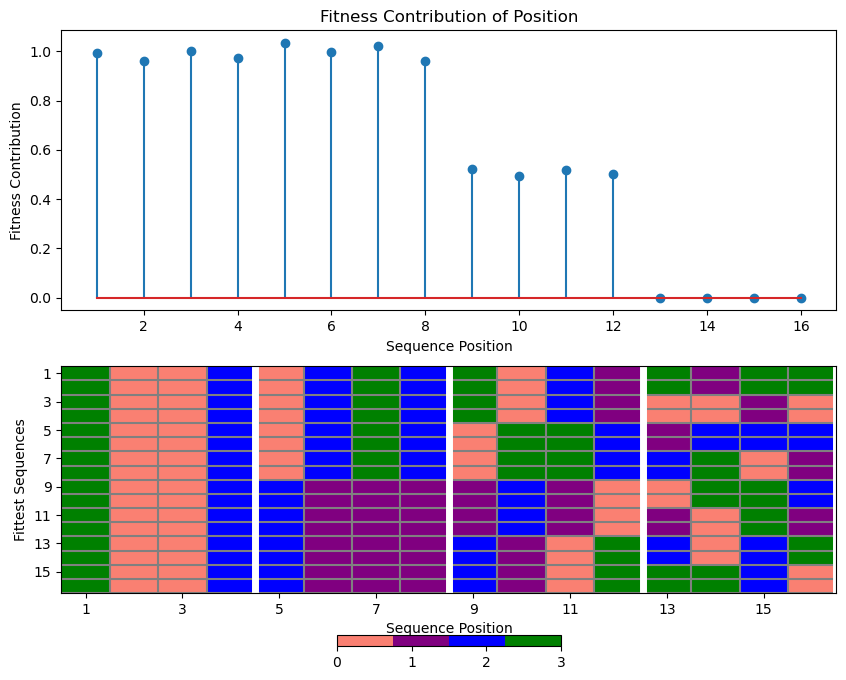

In [9]:
fig, ax = plt.subplots(2,1,figsize=(10,8))
ax[0].stem(range(1, Num_features+1,1), Weights)
ax[0].set_title("Fitness Contribution of Position")
ax[0].set_xlabel("Sequence Position")
ax[0].set_ylabel("Fitness Contribution")

f1= ax[1].imshow(Fitness_Landscape, cmap = Custom_map0,aspect = "auto")
plt.colorbar(f1, ax=ax[1],ticks= Letters, cmap = "Custom_map0", location = "bottom", fraction = 0.04)
ax[1].set_xlabel("Sequence Position")
ax[1].set_ylabel("Fittest Sequences")
ax[1]. set_yticks(range(0, Num_features,2), range(1,Num_features+1,2))
ax[1]. set_xticks(range(0, Num_features,2), range(1,Num_features+1,2))


### guide lines
for i in range(0, np.shape(Fitness_Landscape)[0]):
    ax[1].axhline(i+0.5, color = "gray")
for i in range(0, np.shape(Fitness_Landscape)[1]):
    ax[1].axvline(i+0.5, color = "gray")
for i,elem in enumerate(np.cumsum(Feature_Partition)):
    ax[1].axvline(elem-0.5, linewidth = 5, color = "white")


 
    



In [23]:
## Initialize the Model:
Population_size = 2000
Epochs = 1000

print("-"*80)
Evolver = Evolution_simulation(Feature_Partition, Number_of_letters)
Evolver.Fitness_Sequence = Fitness_Landscape
Evolver.Set_mutation_rate(Mutation_Rate)
Evolver.Set_compete_fraction(Compete_fraction)
Evolver.Weights = Weights
Initial_Population = Evolver.Population(Population_size)
print("-"*80)

--------------------------------------------------------------------------------
--------------------------------------------------------------------------------


In [90]:
### Populations:

Ground_truth_population = np.array(pd.read_csv("../../Training_Data/Toy_Model_Evolution/Training_Data_Final_5000_Ground_Truth_Population.csv"))
LRBM_Generated_population = np.array(pd.read_csv("../../Results/Generated_Data/Toy_Model_Evolution/LRBM_Generated_Population.csv"))
Profile_Model_Generated_population = np.array(pd.read_csv("../../Results/Generated_Data/Toy_Model_Evolution/Profile_Model_Generated_Population.csv"))

In [91]:
def Fitness_Measurement(Population, Model):
    Fitness_array=[]
    for i in range(0, len(Population)):
        f_ind= Model.Fitness_Measurement(Population[i])
        Fitness_array.append(f_ind)
    return np.array(Fitness_array)


def Hamming_Population(state, Array):
    """Computes Hamming distance of a state to the Array"""
    Hamming = np.min(np.sum(Array != state, axis = 1))
    return Hamming

In [92]:
Fitness_Ground_Truth_Population = Fitness_Measurement(Ground_truth_population, Evolver)
Fitness_LRBM_Population = Fitness_Measurement(LRBM_Generated_population, Evolver)
Fitness_Profile_Population = Fitness_Measurement(Profile_Model_Generated_population, Evolver)

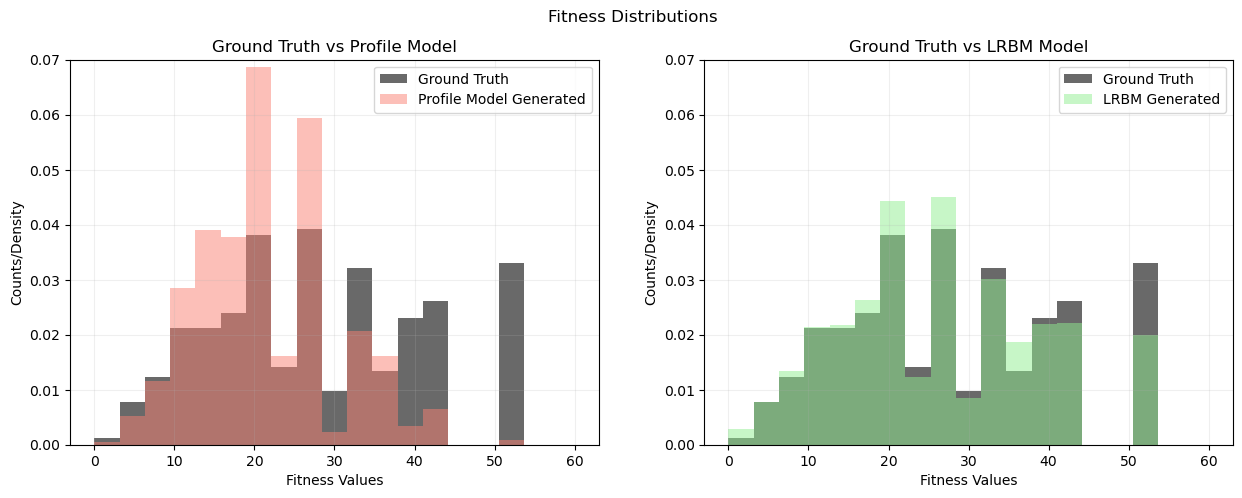

In [93]:
bin_vals = np.linspace(0,60, 20)

fig, ax = plt.subplots(1,2,figsize=(15,5))

ax[0].hist(Fitness_Ground_Truth_Population, bin_vals, color = "dimgray", density = True, label = "Ground Truth")
ax[0].hist(Fitness_Profile_Population, bin_vals, color = "salmon", density = True, alpha = 0.5, label = "Profile Model Generated")
ax[0].grid(alpha = 0.2, zorder = 0)

ax[1].hist(Fitness_Ground_Truth_Population, bin_vals, color = "dimgray", density = True, label = "Ground Truth")
ax[1].hist(Fitness_LRBM_Population, bin_vals, color = "lightgreen", density = True, alpha = 0.5, label = "LRBM Generated")
ax[1].grid(alpha = 0.2, zorder = 0)
ax[0].set_title("Ground Truth vs Profile Model")
ax[1].set_title("Ground Truth vs LRBM Model")

for i in range(0,2):
    ax[i].legend()
    ax[i].set_xlabel("Fitness Values")
    ax[i].set_ylabel("Counts/Density")
    ax[i].set_ylim(0,0.07)

plt.suptitle("Fitness Distributions")
plt.show()

In [151]:
cts_gt, bins = np.histogram(Fitness_Ground_Truth_Population, bin_vals)
cts_lrbm, _=  np.histogram(Fitness_LRBM_Population, bin_vals, bin_vals)
cts_profile, _=  np.histogram(Fitness_Profile_Population, bin_vals, bin_vals)

print("--"*7 + "Pearson Test" +"--"*7)
print("1. Ground Truth Vs LRBM ")
print("|| Pearson Statistics:",np.round(pearsonr(cts_gt, cts_lrbm)[0],4)) 
print("|| Pearson p_value   :=", pearsonr(cts_gt, cts_lrbm)[1])
print("--"*20)
print("2. Ground Truth Vs Profile Model ")
print("|| Pearson Statistics:",np.round(pearsonr(cts_gt, cts_profile)[0],3))
print("|| Pearson p_value   :", pearsonr(cts_gt, cts_profile)[1])
print("--"*20)

--------------Pearson Test--------------
1. Ground Truth Vs LRBM 
|| Pearson Statistics: 0.8947
|| Pearson p_value   := 2.90186603666655e-06
----------------------------------------
2. Ground Truth Vs Profile Model 
|| Pearson Statistics: 0.82
|| Pearson p_value   : 0.00010042874739874297
----------------------------------------


In [152]:
Hamming_LRBM = []
for elem in LRBM_Generated_population:
    h_elem = Hamming_Population(elem, Ground_truth_population)
    Hamming_LRBM.append(h_elem)


Hamming_Profile = []
for elem in Profile_Model_Generated_population:
    h_elem = Hamming_Population(elem, Ground_truth_population)
    Hamming_Profile.append(h_elem)


Hamming_LRBM = np.array(Hamming_LRBM)
Hamming_Profile = np.array(Hamming_Profile)


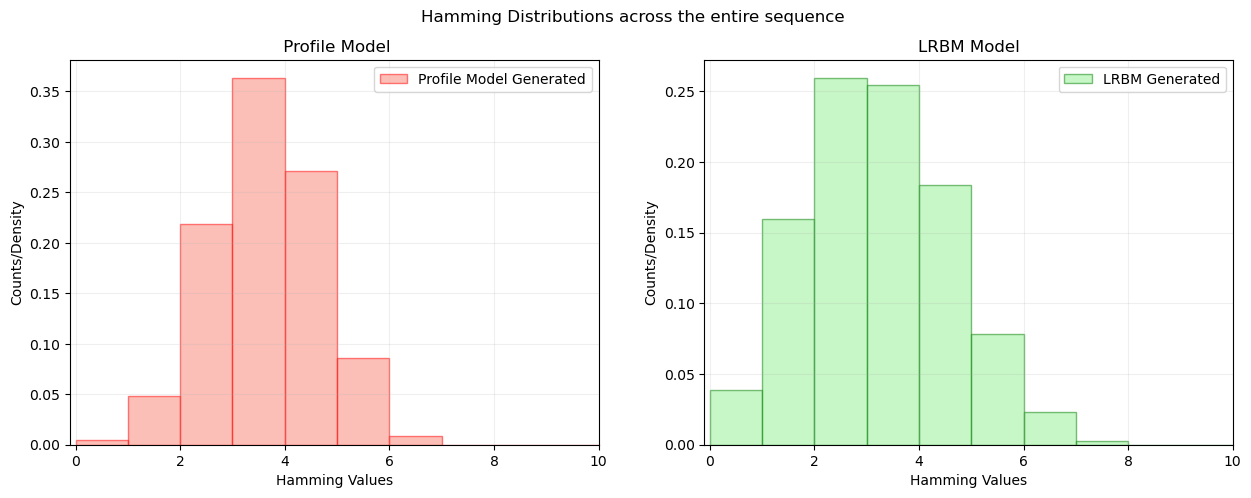

In [160]:
bin_vals = np.linspace(0,16, 17)

fig, ax = plt.subplots(1,2,figsize=(15,5))

ax[0].hist(Hamming_Profile, bin_vals, color = "salmon", density = True, alpha = 0.5,edgecolor = "red", label = "Profile Model Generated")
ax[0].grid(alpha = 0.2, zorder = 0)

ax[1].hist(Hamming_LRBM, bin_vals, color = "lightgreen", density = True, alpha = 0.5, edgecolor = "green", label = "LRBM Generated")
ax[1].grid(alpha = 0.2, zorder = 0)
ax[0].set_title(" Profile Model")
ax[1].set_title("LRBM Model")

for i in range(0,2):
    ax[i].legend()
    ax[i].set_xlabel("Hamming Values")
    ax[i].set_ylabel("Counts/Density")
    ax[i].set_xlim(-0.1, 10)
plt.suptitle("Hamming Distributions across the entire sequence")
plt.show()

### Restricted Hamming:
    Since the last 4 positions have 0 contribution to fitness, they can fluctuate at true random.

    Therefore we can limit the hamming analysis to first 12 positions instead which have non-zero contribution to fitness. 

In [154]:
Hamming_LRBM_rest = []
for elem in LRBM_Generated_population:
    h_elem = Hamming_Population(elem[0:12], Ground_truth_population[:,0:12])
    Hamming_LRBM_rest.append(h_elem)


Hamming_Profile_rest = []
for elem in Profile_Model_Generated_population:
    h_elem = Hamming_Population(elem[0:12], Ground_truth_population[:,0:12])
    Hamming_Profile_rest.append(h_elem)


Hamming_LRBM_rest = np.array(Hamming_LRBM_rest)
Hamming_Profile_rest = np.array(Hamming_Profile_rest)

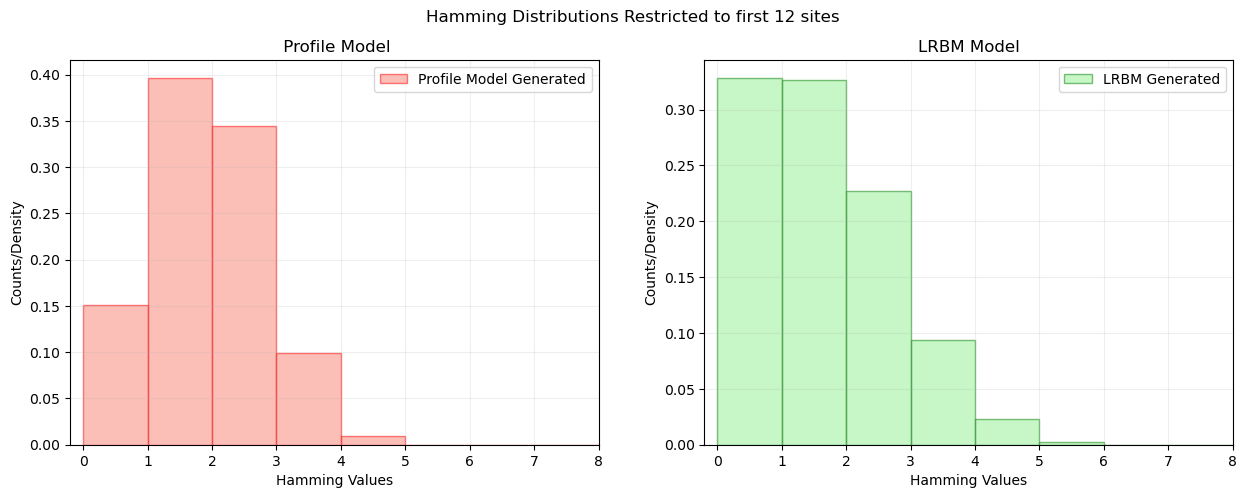

In [161]:
bin_vals = np.linspace(0,16, 17)

fig, ax = plt.subplots(1,2,figsize=(15,5))

ax[0].hist(Hamming_Profile_rest, bin_vals, color = "salmon", density = True, alpha = 0.5, edgecolor = "red" ,label = "Profile Model Generated")
ax[0].grid(alpha = 0.2, zorder = 0)

ax[1].hist(Hamming_LRBM_rest, bin_vals, color = "lightgreen", density = True, alpha = 0.5, edgecolor = "green", label = "LRBM Generated")
ax[1].grid(alpha = 0.2, zorder = 0)
ax[0].set_title(" Profile Model")
ax[1].set_title("LRBM Model")

for i in range(0,2):
    ax[i].legend()
    ax[i].set_xlabel("Hamming Values")
    ax[i].set_ylabel("Counts/Density")
    ax[i].set_xlim(-0.2,8)
plt.suptitle("Hamming Distributions Restricted to first 12 sites")
plt.show()

### This concludes this notebook.